# Spatial Copper Mining in DR Congo - Spatial Foundation

## 1. Spatial foundation

### Set up

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import rioxarray as rxr
from matplotlib.colors import LightSource

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

from obtain_remote_data import (
    COPPERBELT_BBOX,
    DATA_RAW,
    load_full_copperbelt_admin,
    load_mrds,
    load_overture_data,
    load_srtm,
    load_geology_from_local_zips,
)

# Output directory — created automatically if it doesn't exist
MAPS_OUT = PROJECT_ROOT / "outputs" / "maps" / "spatial_foundation"
MAPS_OUT.mkdir(parents=True, exist_ok=True)

### Load data

In [2]:
# Infrastructure (local parquet — filtered to bbox)
infrastructure = gpd.read_parquet(DATA_RAW / "copperbelt_infrastructure.parquet")
infrastructure = infrastructure.cx[
    COPPERBELT_BBOX[0]:COPPERBELT_BBOX[2],
    COPPERBELT_BBOX[1]:COPPERBELT_BBOX[3],
]

roads = load_overture_data(COPPERBELT_BBOX, layer_type="segment")
water = load_overture_data(COPPERBELT_BBOX, layer_type="water")

# Administrative boundaries — positional arg, NOT keyword COPPERBELT_BBOX=
districts = load_full_copperbelt_admin(COPPERBELT_BBOX, level=2)

# MRDS mineral occurrences (reads from cache if available)
mrds = load_mrds(COPPERBELT_BBOX)

# SRTM elevation (reads from existing TIF if available)
srtm_path = DATA_RAW / "srtm_copperbelt.tif"
if srtm_path.exists():
    dem = rxr.open_rasterio(srtm_path).squeeze()
else:
    dem = load_srtm(COPPERBELT_BBOX, output_path=srtm_path)

  Overture 'segment' — 2,544 features carregadas.
  Overture 'water' — 11,776 features carregadas.
  GADM — downloading COD level 2...
    COD: 13 units loaded.
  GADM — downloading ZMB level 2...
    ZMB: 18 units loaded.
  MRDS — lendo cache local: mrds_copperbelt.parquet


### Data processing

In [3]:
# ---- Country boundaries (DRC and Zambia)
countries = districts.dissolve(by="GID_0")
rdc    = countries.loc[["COD"]].geometry.values[0]
zambia = countries.loc[["ZMB"]].geometry.values[0]
boundary = rdc.intersection(zambia)

# ---- Ore classification (top 5 + Others)
mrds["ore_simple"] = mrds["ore"].str.split(",").str[:2].str.join(", ").fillna("Not specified")
top_5 = mrds["ore_simple"].value_counts().nlargest(5).index
mrds["ore_map"] = mrds["ore_simple"].apply(lambda x: x if x in top_5 else "Others")

# ---- Hillshade from SRTM (vertical exaggeration for visual clarity)
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem.values, vert_exag=0.6)


## 1.1 Mining distribution

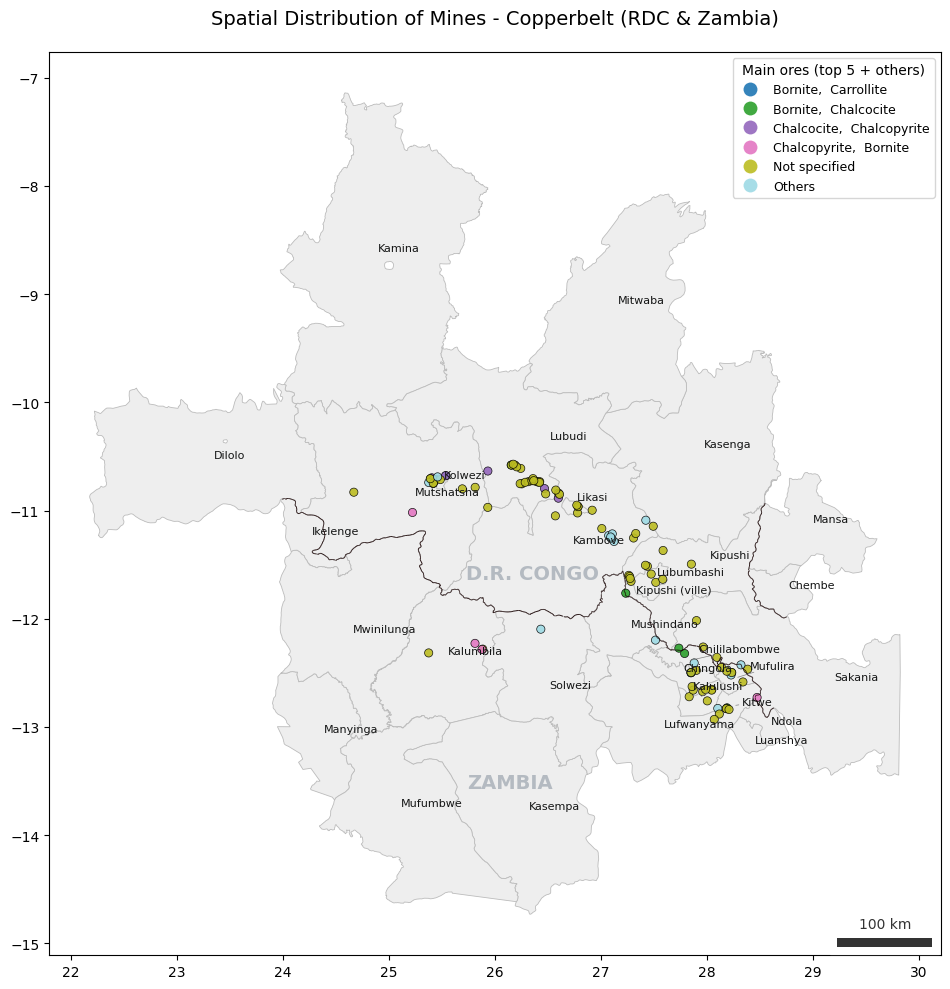

In [31]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

## Plotting
fig, ax = plt.subplots(figsize=(12, 10))

# 1. Base: Copperbelt Districts and Country Border
ax = districts.plot(ax=ax, color='#eeeeee', edgecolor='#bcbcbc', linewidth=0.6)

# District labels (auto-adjusted to avoid overlap)
texts = []
for _, row in districts.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    texts.append(ax.text(x, y, row["NAME_2"], fontsize=8, color="#141515"))

# International boundary
gpd.GeoSeries([boundary]).plot(
    ax=ax, color="#1C0606", linewidth=0.6, linestyle="--",
    zorder=3, label="International Border",
)

# Country labels
from matplotlib.transforms import offset_copy
for iso, row in countries.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    # offset in pixels (dx, dy)
    if iso == "COD":
        dx, dy = 70, -100
    else:
        dx, dy = -5, -55
    text_transform = offset_copy(ax.transData, fig=fig, x=dx, y=dy, units='points')

    ax.text(
        x, y,
        "D.R. CONGO" if iso == "COD" else "ZAMBIA",
        fontsize=14, fontweight="bold", color="#5d6d7e", alpha=0.4,
        transform=text_transform,
        ha="center", va="center", zorder=10
    )

# 2. Ore Mines (colour by ore type)
mrds.plot(ax=ax, column='ore_map', markersize=35, legend=True, 
          categorical=True, cmap='tab20',
          edgecolor='black', linewidth=0.5, alpha=0.9, 
          legend_kwds={'title': "Main ores (top 5 + others)", 
                       'loc': 'upper right', 'fontsize': 9}
)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# 3. Scale bar
dx = 111000 # ~1 degree latitude in metres at this latitude
scalebar = ScaleBar(
    dx=dx, units="m", dimension="si-length", location="lower right",
    fixed_value=100, fixed_units="km", frameon=True, color="#333333",
    box_alpha=0.5, pad=0.5, scale_loc="top", rotation="horizontal-only",
    label_formatter=lambda v, u: f"{v:.0f} {u}",
)

ax.set_title("Spatial Distribution of Mines - Copperbelt (RDC & Zambia)", fontsize=14, pad=20)
ax.axis('on')
ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig(MAPS_OUT / "mine_distribution.png", dpi=300)
plt.show()

## 1.2 Infrastructure

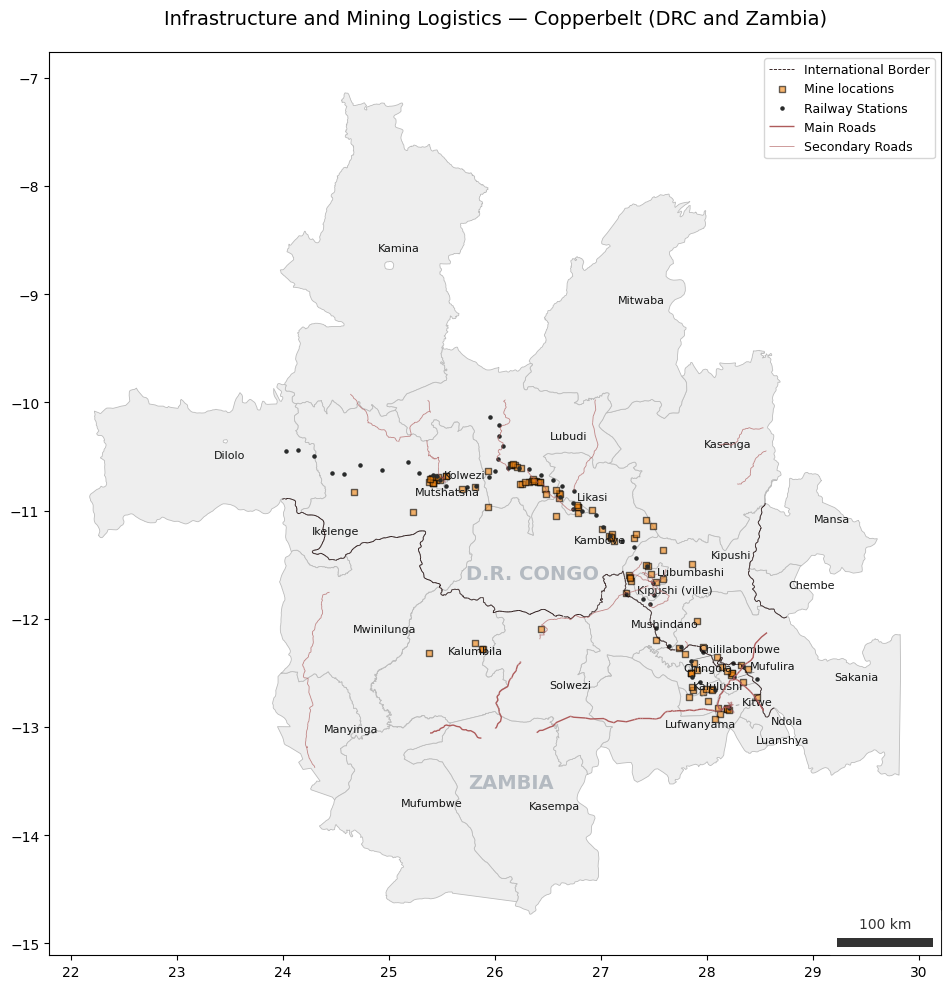

In [32]:
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_aspect("equal")

# 1. Base: Copperbelt Districts and Country Border
ax = districts.plot(ax=ax, color="#eeeeee", edgecolor="#bcbcbc", linewidth=0.6)

# District labels (auto-adjusted to avoid overlap)
texts = []
for _, row in districts.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    texts.append(ax.text(x, y, row["NAME_2"], fontsize=8, color="#141515"))

# International boundary
gpd.GeoSeries([boundary]).plot(
    ax=ax, color="#1C0606", linewidth=0.6, linestyle="--",
    zorder=3, label="International Border",
)

# Country labels
from matplotlib.transforms import offset_copy
for iso, row in countries.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    # offset in pixels (dx, dy)
    if iso == "COD":
        dx, dy = 70, -100
    else:
        dx, dy = -5, -55
    text_transform = offset_copy(ax.transData, fig=fig, x=dx, y=dy, units='points')

    ax.text(
        x, y,
        "D.R. CONGO" if iso == "COD" else "ZAMBIA",
        fontsize=14, fontweight="bold", color="#5d6d7e", alpha=0.4,
        transform=text_transform,
        ha="center", va="center", zorder=10
    )

# 2. Mine locations
mrds.plot(ax=ax, color="#f1840f", edgecolor="black",
          markersize=20, marker="s", alpha=0.6, zorder=1, label="Mine locations")

# 3. Infrastructure
# Railway stations
infrastructure[infrastructure["class"] == "railway_station"].plot(
    ax=ax, color="#292B2B", markersize=5, linewidth=1,
    label="Railway Stations", zorder=2,
)

# Roads
roads[roads["class"].isin(["motorway", "primary"])].plot(
    ax=ax, color="#ae5b5b", linewidth=1, label="Main Roads", zorder=4,
)
roads[roads["class"] == "secondary"].plot(
    ax=ax, color="#ae5b5b", linewidth=0.6, alpha=0.7, label="Secondary Roads", zorder=5,
)

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

# 4. Scale bar
dx = 111000 # ~1 degree latitude in metres at this latitude
scalebar = ScaleBar(
    dx=dx, units="m", dimension="si-length", location="lower right",
    fixed_value=100, fixed_units="km", frameon=True, color="#333333",
    box_alpha=0.5, pad=0.5, scale_loc="top", rotation="horizontal-only",
    label_formatter=lambda v, u: f"{v:.0f} {u}",
)

ax.set_title("Infrastructure and Mining Logistics — Copperbelt (DRC and Zambia)", fontsize=14, pad=20)
ax.axis("on")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper right", frameon=True, fontsize=9)
ax.add_artist(scalebar)
plt.tight_layout()
plt.savefig(MAPS_OUT / "infrastructure.png", dpi=300)
plt.show()

## 1.3 Terrain and Mine locations

C:\Users\jlima\AppData\Local\Temp\ipykernel_13808\2960807100.py:53: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", frameon=True)


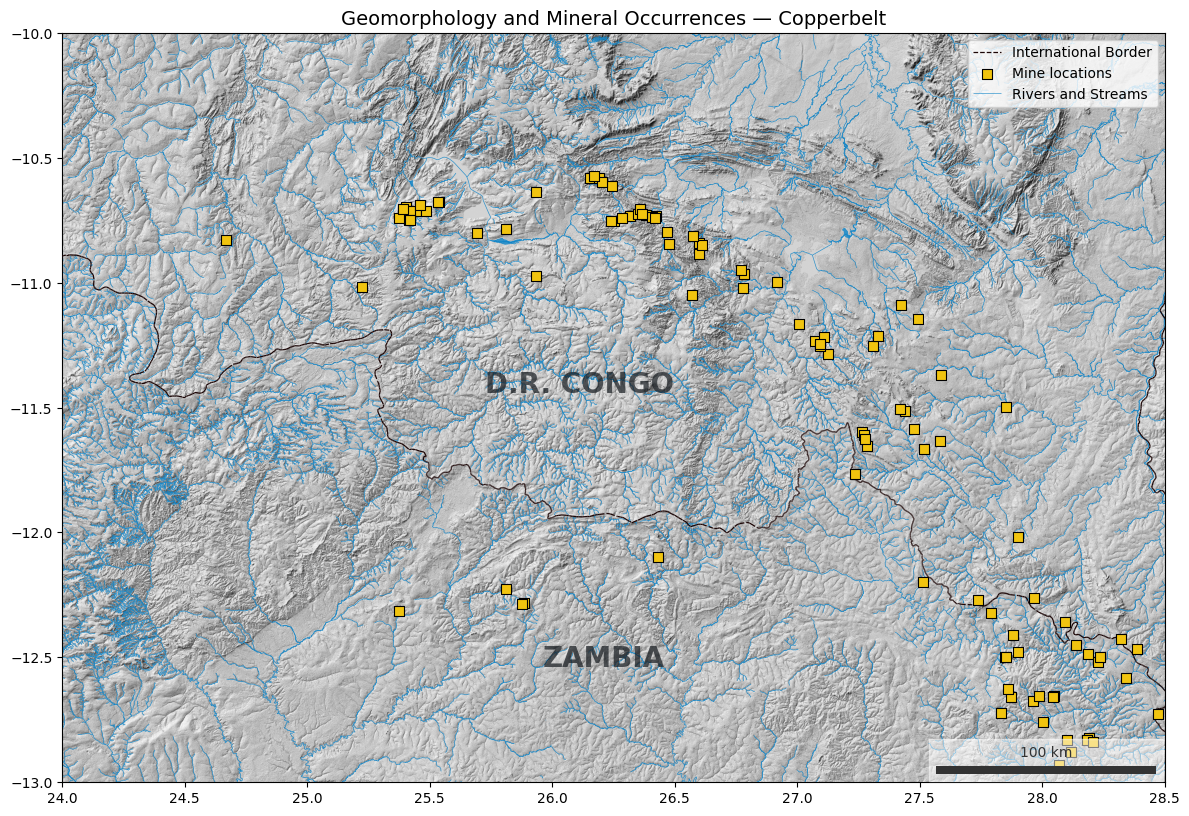

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

extents = [float(dem.x.min()), float(dem.x.max()), float(dem.y.min()), float(dem.y.max())]
ax.imshow(hillshade, cmap="gray", extent=extents, origin="upper")

# 1. Base: Country Border
# International boundary
gpd.GeoSeries([boundary]).plot(
    ax=ax, color="#1C0606", linewidth=0.9, linestyle="--",
    zorder=3, label="International Border",
)

# Country labels
from matplotlib.transforms import offset_copy
for iso, row in countries.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    # offset in pixels (dx, dy)
    if iso == "COD":
        dx, dy = 120, -200
    else:
        dx, dy = 0, 55
    text_transform = offset_copy(ax.transData, fig=fig, x=dx, y=dy, units='points')

    ax.text(
        x, y,
        "D.R. CONGO" if iso == "COD" else "ZAMBIA",
        fontsize=20, fontweight="bold", color="#14191e", alpha=0.7,
        transform=text_transform,
        ha="center", va="center", zorder=10
    )

# 2. Mine locations
mrds.plot(ax=ax, color="#f1c40f", markersize=45, marker="s",
          edgecolor="black", linewidth=0.8, label="Mine locations", 
          zorder=4)

# 3. Water streams
water.plot(ax=ax, color="#0982C7", linewidth=0.5, alpha=0.8, 
           label="Rivers and Streams", zorder=1)

# 4. Scale bar
dx = 111000 # ~1 degree latitude in metres at this latitude
scalebar = ScaleBar(
    dx=dx, units="m", dimension="si-length", location="lower right",
    fixed_value=100, fixed_units="km", frameon=True, color="#333333",
    box_alpha=0.5, pad=0.5, scale_loc="top", rotation="horizontal-only",
    label_formatter=lambda v, u: f"{v:.0f} {u}",
)

ax.set_title("Geomorphology and Mineral Occurrences — Copperbelt", 
             fontsize=14)
ax.axis("on")
ax.legend(loc="upper right", frameon=True)
ax.set_xlim(COPPERBELT_BBOX[0], COPPERBELT_BBOX[2])
ax.set_ylim(COPPERBELT_BBOX[1], COPPERBELT_BBOX[3])
ax.add_artist(scalebar)
plt.tight_layout()
plt.savefig(MAPS_OUT / "geomorphology.png", dpi=300)
plt.show()

## 1.4 Geology

In [53]:
geo = load_geology_from_local_zips(COPPERBELT_BBOX)

# Inspect columns to find the right field for lithology / age / unit name
print("\nColumns:", geo.columns.tolist())
geo.head(3)


  Geology — reading local cache: geology_copperbelt.geojson

Columns: ['AREA', 'PERIMETER', 'GEO2_7G_', 'GEO2_7G_ID', 'GLG', 'short_name', 'long_name', 'name', 'color', 'era', 'order', '_source_zip', '_source_shp', 'geometry']


,AREA,PERIMETER,GEO2_7G_,GEO2_7G_ID,GLG,short_name,long_name,name,color,era,order,_source_zip,_source_shp,geometry
0,451.86540,1503.36548,7275,7475,pCm,pCm,Precambrian,Precambrian,#F7437C,Precambrian,1.0,Africa_Geology_Data_Shapefile-main.zip,Africa_Geological_Data.shp,"POLYGON ((13.17258 -5.86386, 13.17888 -5.85633..."
1,137.07593,513.14624,9392,9351,QT,QT,Cenozoic,Cenozoic,#FEF21C,Cenozoic,39.0,Africa_Geology_Data_Shapefile-main.zip,Africa_Geological_Data.shp,"POLYGON ((18.30249 -4.87173, 18.30664 -4.86363..."
2,2.18196,31.17422,9650,9605,QT,QT,Cenozoic,Cenozoic,#FEF21C,Cenozoic,39.0,Africa_Geology_Data_Shapefile-main.zip,Africa_Geological_Data.shp,"POLYGON ((25.41323 -8.66972, 25.40596 -8.67387..."


In [56]:
litho = geo["long_name"]
print(litho.unique())

<ArrowStringArray>
[           'Precambrian',               'Cenozoic',               'Holocene',
  'Permian-Carboniferous',  'Water (River or Lake)', 'Quaternary (undivided)',
                      nan]
Length: 7, dtype: str


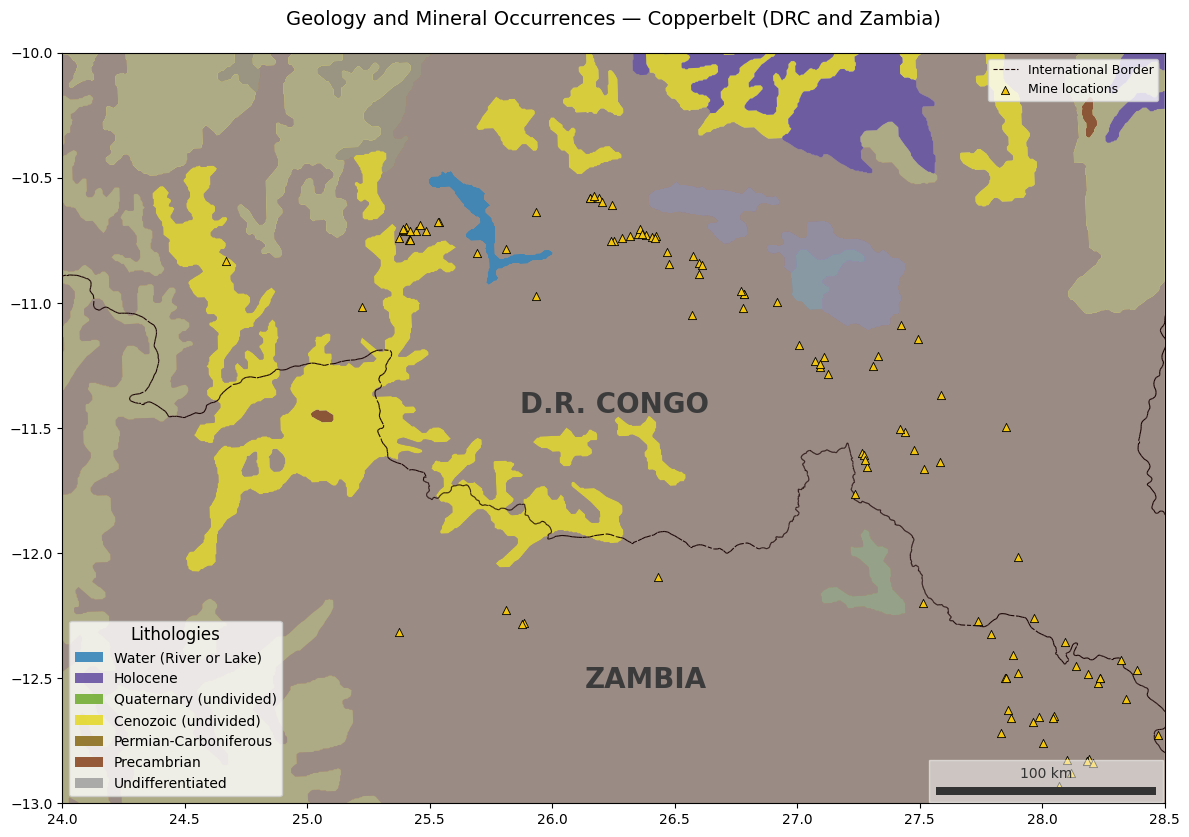

In [74]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Patch
import matplotlib.cm as cm
import pandas as pd
from shapely.geometry import box

bbox_poly = box(*COPPERBELT_BBOX)
geo_clip = geo.clip(bbox_poly)

# Process geology categories for plotting
litho = geo_clip["long_name"]
geo_clip["long_name"] = geo_clip["long_name"].fillna("Undifferentiated")
geo_clip["long_name"] = geo_clip["long_name"].replace({"Cenozoic": "Cenozoic (undivided)"})

ordered_units = [
    "Water (River or Lake)",
    "Holocene",
    "Quaternary (undivided)",
    "Cenozoic (undivided)",
    "Permian-Carboniferous",
    "Precambrian",
    "Undifferentiated"
]

geo_clip["_plot_cat"] = geo_clip["long_name"].where(
    geo_clip["long_name"].isin(ordered_units[:-1]),
    other="Undifferentiated"
)

geo_clip["_plot_cat"] = pd.Categorical(
    geo_clip["_plot_cat"],
    categories=ordered_units,
    ordered=True
)

color_map = {
    "Water (River or Lake)": "#1f78b4",
    "Holocene": "#583f9b",
    "Quaternary (undivided)": "#66a61e",
    "Cenozoic (undivided)": "#e3d615",
    "Permian-Carboniferous": "#806006",
    "Precambrian": "#7f360e",
    "Undifferentiated": "#999999"
}

geo_clip["_color"] = geo_clip["_plot_cat"].map(color_map)
geo_clip["_color"] = geo_clip["_color"].fillna("#999999")

fig, ax = plt.subplots(figsize=(12, 10))

# --- Geology base layer
geo_clip.plot(
    ax=ax,
    color=geo_clip["_color"],
    edgecolor="none",
    alpha=0.75,
)

# --- International boundary
gpd.GeoSeries([boundary]).plot(
    ax=ax, color="#1C0606", linewidth=0.8, linestyle="--",
    zorder=4, label="International Border",
)

# --- Mine locations
mrds.plot(
    ax=ax, color="#f1c40f", markersize=35, marker="^",
    edgecolor="black", linewidth=0.6, zorder=5, label="Mine locations",
)

# --- Country labels
from matplotlib.transforms import offset_copy
for iso, row in countries.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    # offset in pixels (dx, dy)
    if iso == "COD":
        dx, dy = 145, -200
    else:
        dx, dy = 30, 55
    text_transform = offset_copy(ax.transData, fig=fig, x=dx, y=dy, units='points')

    ax.text(
        x, y,
        "D.R. CONGO" if iso == "COD" else "ZAMBIA",
        fontsize=20, fontweight="bold", color="#14191e", alpha=0.7,
        transform=text_transform,
        ha="center", va="center", zorder=10
    )

# --- Legends
# Geology categories
geo_patches = [
    Patch(facecolor=color_map[cat], edgecolor="none", label=cat, alpha=0.8)
    for cat in ordered_units
    if cat in geo_clip["_plot_cat"].unique()
]

geo_legend = ax.legend(
    handles=geo_patches,
    title="Lithologies",
    loc="lower left",
    fontsize=10,
    title_fontsize=12,
    frameon=True,
    ncol=1,
)
ax.add_artist(geo_legend)

# Mine + border legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper right", frameon=True, fontsize=9)

# --- Scale bar
dx = 111000 # ~1 degree latitude in metres at this latitude
scalebar = ScaleBar(
    dx=dx, units="m", dimension="si-length", location="lower right",
    fixed_value=100, fixed_units="km", frameon=True, color="#333333",
    box_alpha=0.5, pad=0.5, scale_loc="top", rotation="horizontal-only",
    label_formatter=lambda v, u: f"{v:.0f} {u}",
)
ax.add_artist(scalebar)

ax.set_xlim(COPPERBELT_BBOX[0], COPPERBELT_BBOX[2])
ax.set_ylim(COPPERBELT_BBOX[1], COPPERBELT_BBOX[3])
ax.set_title("Geology and Mineral Occurrences — Copperbelt (DRC and Zambia)", fontsize=14, pad=20)
ax.axis("on")
plt.tight_layout()
plt.savefig(MAPS_OUT / "geology.png", dpi=300)
plt.show()